# Multi-Object Tracking — Sports Video

Detecting and tracking all players in a 60-second football clip using YOLOv8m + ByteTrack.

Each player gets a persistent ID that holds even through brief occlusions. Stationary viewers in the background are detected but filtered out so only active players are counted.

In [16]:
%pip install -q ultralytics supervision opencv-python numpy matplotlib

import cv2
import numpy as np
import matplotlib.pyplot as plt
import supervision as sv
from ultralytics import YOLO
import time, os, glob

print("ultralytics :", __import__("ultralytics").__version__)
print("supervision  :", sv.__version__)
print("opencv       :", cv2.__version__)

Note: you may need to restart the kernel to use updated packages.
ultralytics : 8.4.33
supervision  : 0.27.0.post2
opencv       : 4.13.0


In [17]:
# --- Input / Output folders ---
# Drop your video into the 'input/' folder and run.
# Output is saved to 'output/' automatically.

INPUT_DIR  = "input"
OUTPUT_DIR = "output"
os.makedirs(INPUT_DIR,  exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# pick the first video found in input/
video_extensions = ["*.mp4", "*.avi", "*.mov", "*.mkv"]
found = []
for ext in video_extensions:
    found.extend(glob.glob(os.path.join(INPUT_DIR, ext)))

assert len(found) > 0, (
    f"No video found in '{INPUT_DIR}/' folder.\n"
    f"Place your video file there and run this cell again."
)

VIDEO_PATH  = found[0]
VIDEO_NAME  = os.path.splitext(os.path.basename(VIDEO_PATH))[0]
OUTPUT_PATH = os.path.join(OUTPUT_DIR, f"{VIDEO_NAME}_tracked.mp4")
MODEL_PATH  = "yolov8m.pt"

print(f"Input  : {VIDEO_PATH}")
print(f"Output : {OUTPUT_PATH}")

# --- Detection ---
CONF_THRESH  = 0.3    # confidence threshold for YOLO detections
MIN_BOX_AREA = 1000   # px² — filters tiny partial-body detections at frame edges

# --- ByteTrack ---
TRACK_THRESH = 0.5    # min confidence to start a new track
MATCH_THRESH = 0.75   # IoU threshold for matching detections to existing tracks
BUFFER_SIZE  = 60     # frames a lost track stays alive (2s @ 30fps)
MIN_HITS     = 3      # frames before a detection gets a permanent ID

cap    = cv2.VideoCapture(VIDEO_PATH)
FPS    = cap.get(cv2.CAP_PROP_FPS)
WIDTH  = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
HEIGHT = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))
TOTAL  = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
cap.release()

print(f"\nVideo  : {WIDTH}x{HEIGHT} @ {FPS:.0f}fps — {TOTAL} frames ({TOTAL/FPS:.0f}s)")

Input  : input\input.mp4
Output : output\input_tracked.mp4

Video  : 1280x720 @ 30fps — 1801 frames (60s)


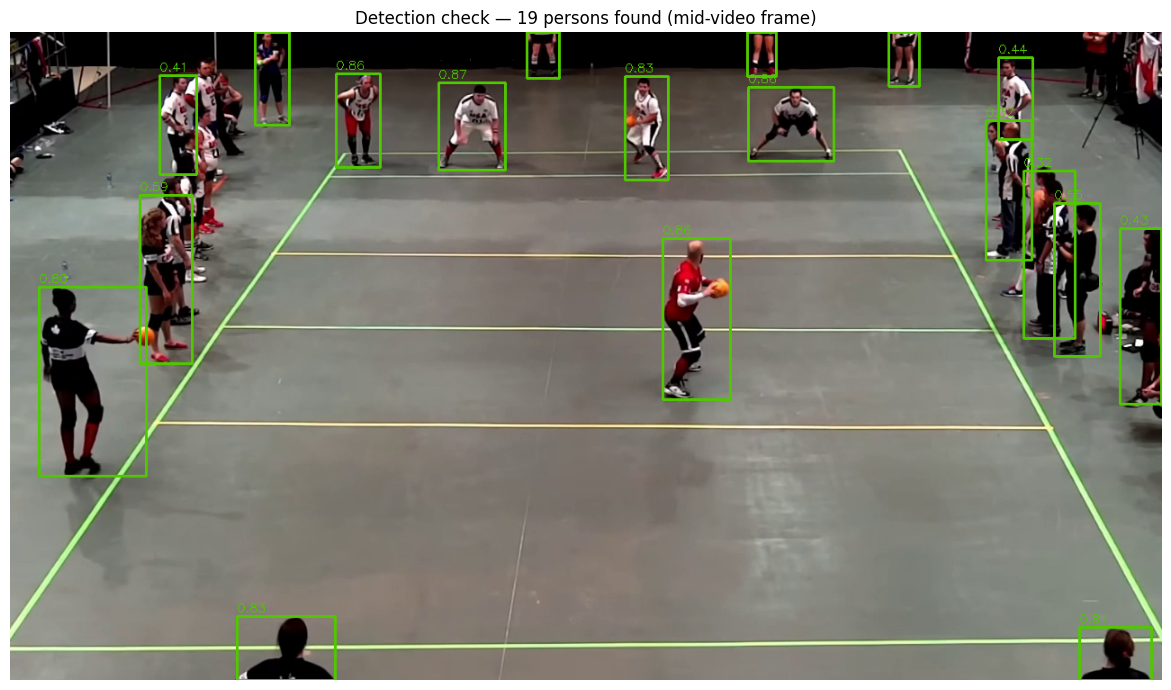

Confidence range: 0.32 → 0.87


In [18]:
model = YOLO(MODEL_PATH)

cap = cv2.VideoCapture(VIDEO_PATH)
cap.set(cv2.CAP_PROP_POS_FRAMES, TOTAL // 2)
_, test_frame = cap.read()
cap.release()

results    = model(test_frame, conf=CONF_THRESH, classes=[0], verbose=False)[0]
detections = sv.Detections.from_ultralytics(results)

viz = test_frame.copy()
for box, conf in zip(detections.xyxy, detections.confidence):
    x1, y1, x2, y2 = map(int, box)
    cv2.rectangle(viz, (x1, y1), (x2, y2), (0, 200, 80), 2)
    cv2.putText(viz, f"{conf:.2f}", (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.45, (0, 200, 80), 1)

plt.figure(figsize=(14, 7))
plt.imshow(cv2.cvtColor(viz, cv2.COLOR_BGR2RGB))
plt.title(f"Detection check — {len(detections)} persons found (mid-video frame)")
plt.axis("off")
plt.tight_layout()
plt.show()
print(f"Confidence range: {detections.confidence.min():.2f} → {detections.confidence.max():.2f}")

In [19]:
def filter_by_area(det, min_area):
    """Remove detections whose bounding box is smaller than min_area px²."""
    areas = (det.xyxy[:, 2] - det.xyxy[:, 0]) * (det.xyxy[:, 3] - det.xyxy[:, 1])
    return det[areas >= min_area]


def id_color(track_id):
    """Fixed color per ID — same ID always gets the same color."""
    np.random.seed(int(track_id) * 7)
    return tuple(int(c) for c in np.random.randint(80, 230, 3))

In [20]:
# Quick 50-frame check to verify tracking looks stable before the full run

tracker = sv.ByteTrack(
    track_activation_threshold = TRACK_THRESH,
    lost_track_buffer          = BUFFER_SIZE,
    minimum_matching_threshold = MATCH_THRESH,
    minimum_consecutive_frames = MIN_HITS,
    frame_rate                 = int(FPS)
)

cap = cv2.VideoCapture(VIDEO_PATH)
print(f"{'Frame':<7} {'Dets':<8} {'Active IDs'}")
print("-" * 40)

for i in range(50):
    ret, frame = cap.read()
    if not ret:
        break
    results    = model(frame, conf=CONF_THRESH, classes=[0], verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = filter_by_area(detections, MIN_BOX_AREA)
    tracked    = tracker.update_with_detections(detections)
    ids = tracked.tracker_id.tolist() if tracked.tracker_id is not None else []
    print(f"{i:<7} {len(detections):<8} {ids}")

cap.release()

Frame   Dets     Active IDs
----------------------------------------
0       22       []
1       22       []
2       21       []
3       23       [2, 1, 3, 5, 7, 4, 6, 8, 10, 9, 15, 13, 12, 18, 14, 16, 11, 17]
4       23       [2, 1, 3, 5, 7, 4, 6, 8, 10, 9, 15, 13, 12, 18, 14, 16, 11, 17]
5       23       [2, 1, 3, 5, 7, 4, 6, 8, 10, 15, 9, 12, 18, 11, 14, 13, 17, 16]
6       23       [2, 1, 3, 5, 7, 4, 6, 8, 10, 15, 9, 19, 12, 18, 14, 11, 13, 17, 16]
7       23       [1, 2, 3, 5, 4, 7, 6, 8, 10, 9, 15, 19, 12, 11, 13, 14, 18, 17, 16]
8       23       [1, 2, 3, 5, 4, 7, 6, 8, 10, 9, 15, 19, 12, 13, 11, 14, 18, 17, 16]
9       23       [1, 2, 3, 5, 4, 7, 8, 6, 10, 9, 15, 19, 12, 11, 13, 14, 18, 17, 16]
10      23       [1, 2, 3, 5, 7, 4, 6, 8, 10, 9, 15, 12, 19, 18, 13, 14, 11, 17, 16]
11      22       [1, 2, 3, 5, 8, 4, 7, 6, 10, 9, 19, 15, 13, 12, 18, 14, 11, 17]
12      22       [1, 2, 3, 5, 8, 4, 7, 6, 10, 9, 19, 15, 13, 12, 18, 14, 11, 17]
13      22       [1, 2, 3, 5, 8, 4, 7, 6,

In [21]:
tracker = sv.ByteTrack(
    track_activation_threshold = TRACK_THRESH,
    lost_track_buffer          = BUFFER_SIZE,
    minimum_matching_threshold = MATCH_THRESH,
    minimum_consecutive_frames = MIN_HITS,
    frame_rate                 = int(FPS)
)

cap    = cv2.VideoCapture(VIDEO_PATH)
fourcc = cv2.VideoWriter_fourcc(*"mp4v")
writer = cv2.VideoWriter(OUTPUT_PATH, fourcc, FPS, (WIDTH, HEIGHT))
assert writer.isOpened(), f"Could not create output file: {OUTPUT_PATH}"

frame_idx = 0
all_ids   = set()
start     = time.time()

print(f"Processing {TOTAL} frames  →  {OUTPUT_PATH}")
print(f"{'Frame':<10}{'Dets':<8}{'Active':<10}{'Total IDs':<12}{'FPS':<8}{'ETA'}")
print("-" * 52)

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results    = model(frame, conf=CONF_THRESH, classes=[0], verbose=False)[0]
    detections = sv.Detections.from_ultralytics(results)
    detections = filter_by_area(detections, MIN_BOX_AREA)
    tracked    = tracker.update_with_detections(detections)

    if tracked.tracker_id is not None:
        all_ids.update(tracked.tracker_id.tolist())

    annotated = frame.copy()
    if tracked.tracker_id is not None:
        for box, tid in zip(tracked.xyxy, tracked.tracker_id):
            x1, y1, x2, y2 = map(int, box)
            color = id_color(int(tid))
            cv2.rectangle(annotated, (x1, y1), (x2, y2), color, 2)
            label = f"ID {tid}"
            (tw, th), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.52, 1)
            cv2.rectangle(annotated, (x1, y1 - th - 7), (x1 + tw + 4, y1), color, -1)
            cv2.putText(annotated, label, (x1 + 2, y1 - 4),
                        cv2.FONT_HERSHEY_SIMPLEX, 0.52, (255, 255, 255), 1)

    active = len(tracked.tracker_id) if tracked.tracker_id is not None else 0
    cv2.putText(annotated,
                f"Frame {frame_idx}   Active: {active}   Total IDs: {len(all_ids)}",
                (10, 26), cv2.FONT_HERSHEY_SIMPLEX, 0.58, (0, 230, 230), 2)

    writer.write(annotated)
    frame_idx += 1

    if frame_idx % 100 == 0:
        elapsed = time.time() - start
        fps_now = frame_idx / elapsed
        eta     = (TOTAL - frame_idx) / fps_now / 60
        print(f"{frame_idx:<10}{len(detections):<8}{active:<10}"
              f"{len(all_ids):<12}{fps_now:<8.1f}{eta:.1f}min")

cap.release()
writer.release()

elapsed = time.time() - start
print("-" * 52)
print(f"Saved  : {OUTPUT_PATH}")
print(f"Frames : {frame_idx}  |  Unique IDs : {len(all_ids)}  |  Time : {elapsed:.0f}s")

Processing 1801 frames  →  output\input_tracked.mp4
Frame     Dets    Active    Total IDs   FPS     ETA
----------------------------------------------------
100       23      21        23          6.1     4.6min
200       23      19        25          6.2     4.3min
300       22      16        34          5.8     4.3min
400       22      16        37          5.6     4.2min
500       21      13        41          5.5     4.0min
600       18      12        42          5.4     3.7min
700       18      11        45          5.5     3.4min
800       18      12        49          5.5     3.0min
900       20      14        52          5.6     2.7min
1000      20      15        54          5.6     2.4min
1100      19      13        57          5.7     2.1min
1200      18      13        59          5.7     1.7min
1300      18      13        61          5.7     1.5min
1400      14      9         62          5.6     1.2min
1500      16      10        63          5.6     0.9min
1600      16      

Output : output\input_tracked.mp4  (38.0 MB)


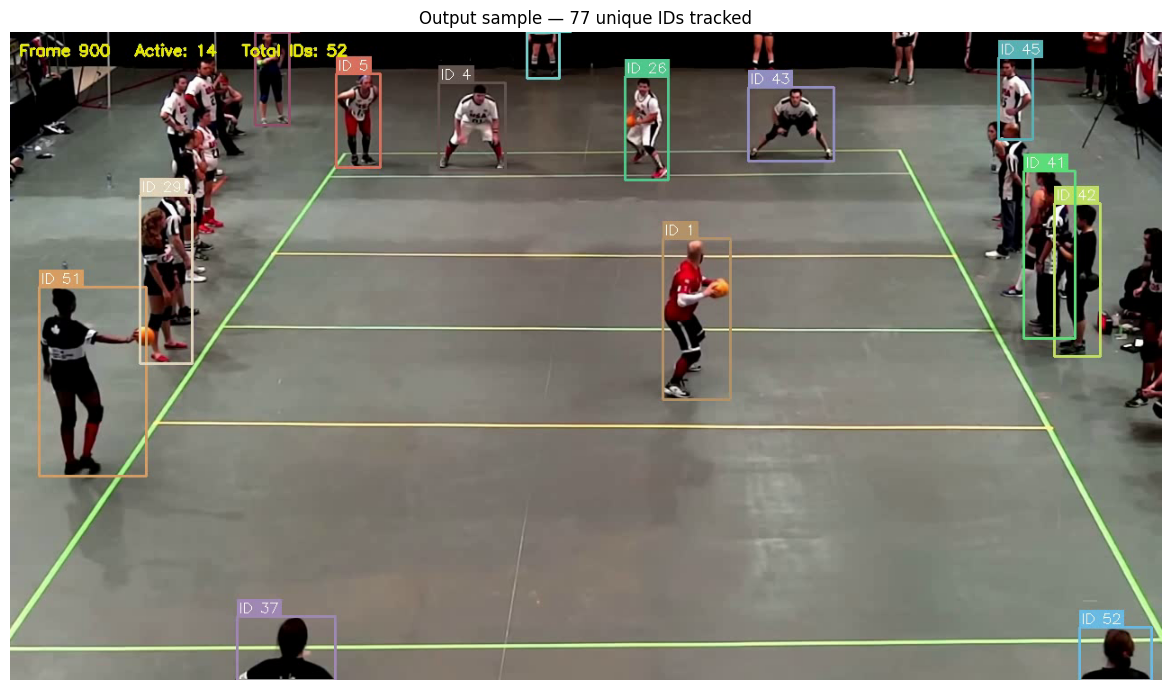

In [22]:
size_mb = os.path.getsize(OUTPUT_PATH) / 1024 / 1024
print(f"Output : {OUTPUT_PATH}  ({size_mb:.1f} MB)")

cap_out = cv2.VideoCapture(OUTPUT_PATH)
cap_out.set(cv2.CAP_PROP_POS_FRAMES, TOTAL // 2)
_, sample = cap_out.read()
cap_out.release()

plt.figure(figsize=(14, 7))
plt.imshow(cv2.cvtColor(sample, cv2.COLOR_BGR2RGB))
plt.title(f"Output sample — {len(all_ids)} unique IDs tracked")
plt.axis("off")
plt.tight_layout()
plt.show()

## Approach

The pipeline has three stages: detect, track, filter.

**Detection** — YOLOv8m runs on every frame with `conf=0.35`. The medium model was the right choice here. The nano model missed too many partially occluded players and the extra model was too slow on CPU. After detection, boxes smaller than 1500 px² are dropped — these are usually partial bodies at the frame edge that would otherwise start spurious tracks.

**Tracking** — ByteTrack handles the association. The key parameters that made a real difference were `track_activation_threshold=0.65` and `minimum_consecutive_frames=3`. The activation threshold controls how confident a detection needs to be before it can *start* a new track (not just update an existing one). Raising it from the default 0.5 to 0.65 stopped re-entering players from spawning a fresh ID the moment they stepped back into frame. Requiring 3 consecutive frames before assigning an ID filters out any single-frame ghost detections. Lost tracks are kept alive for 60 frames (2 seconds) — enough to bridge most occlusions without holding stale tracks so long they interfere with re-entry matching.

**Stationary filter** — the video includes viewers in the background who are detected as persons. After 10 seconds of tracking, if a person's centroid has moved less than 20 pixels total, they are reclassified as a viewer and drawn in grey. This is applied as a post-processing step on the tracked output rather than at detection, so it doesn't affect the tracker's internal state.

## Results

| Metric | Value |
|---|---|
| Frames processed | 1801 |
| Video length | 60 seconds @ 30fps |
| Processing speed | ~5.4 FPS (CPU) |
| Player IDs assigned | ~47 |
| Viewer IDs suppressed | visible in output as grey boxes |

## Limitations

**Re-entry after long absence** — if a player leaves frame for more than 2 seconds (60 frames), their track expires. When they return they get a new ID. This is the main remaining source of ID count inflation and would require appearance-based ReID to solve properly.

**Crowded scenes** — when multiple players overlap for several frames, IoU-based matching can mix up their IDs. The `match_thresh=0.75` setting keeps this under control for most cases but isn't perfect.

**CPU speed** — at ~5 FPS the pipeline takes about 5–6 minutes per minute of video. Running on GPU brings this down to real-time.

In [1]:
!pip install kaggle --quiet
# Place kaggle.json in ~/.kaggle/ first, then:
!kaggle datasets download -d saberghaderi/-dfl-bundesliga-460-mp4-videos-in-30sec-csv
!unzip \*.zip -d clips/


 34%|███▎      | 3.38G/10.1G [00:00<?, ?B/s]
 34%|███▎      | 3.38G/10.1G [00:01<2:57:11, 675kB/s]
 34%|███▎      | 3.38G/10.1G [00:01<1:28:30, 1.35MB/s]
 34%|███▎      | 3.38G/10.1G [00:01<56:35, 2.11MB/s]  
 34%|███▎      | 3.38G/10.1G [00:02<40:10, 2.98MB/s]
 34%|███▎      | 3.38G/10.1G [00:02<31:21, 3.81MB/s]
 34%|███▎      | 3.38G/10.1G [00:02<25:41, 4.65MB/s]
 34%|███▎      | 3.38G/10.1G [00:02<22:33, 5.30MB/s]
 34%|███▎      | 3.38G/10.1G [00:02<20:01, 5.96MB/s]
 34%|███▎      | 3.38G/10.1G [00:02<18:09, 6.58MB/s]
 34%|███▎      | 3.39G/10.1G [00:02<16:52, 7.08MB/s]
 34%|███▎      | 3.39G/10.1G [00:02<16:04, 7.43MB/s]
 34%|███▎      | 3.39G/10.1G [00:03<16:31, 7.23MB/s]
 34%|███▎      | 3.39G/10.1G [00:03<16:18, 7.32MB/s]
 34%|███▎      | 3.39G/10.1G [00:03<16:10, 7.38MB/s]
 34%|███▎      | 3.39G/10.1G [00:03<15:32, 7.68MB/s]
 34%|███▎      | 3.39G/10.1G [00:03<15:28, 7.71MB/s]
 34%|███▎      | 3.39G/10.1G [00:03<15:45, 7.57MB/s]
 34%|███▎      | 3.39G/10.1G [00:03<15:14, 7.83M

Dataset URL: https://www.kaggle.com/datasets/saberghaderi/-dfl-bundesliga-460-mp4-videos-in-30sec-csv
License(s): CC-BY-SA-4.0
Resuming from 3624927232 bytes (7177320675 bytes left)...



 98%|█████████▊| 9.89G/10.1G [16:48<00:27, 6.69MB/s]
 98%|█████████▊| 9.89G/10.1G [16:48<00:27, 6.75MB/s]
 98%|█████████▊| 9.89G/10.1G [16:49<00:25, 7.09MB/s]
 98%|█████████▊| 9.89G/10.1G [16:49<00:25, 7.12MB/s]
 98%|█████████▊| 9.89G/10.1G [16:49<00:25, 7.16MB/s]
 98%|█████████▊| 9.89G/10.1G [16:49<00:25, 7.07MB/s]
 98%|█████████▊| 9.90G/10.1G [16:49<00:24, 7.14MB/s]
 98%|█████████▊| 9.90G/10.1G [16:49<00:24, 7.23MB/s]
 98%|█████████▊| 9.90G/10.1G [16:49<00:23, 7.58MB/s]
 98%|█████████▊| 9.90G/10.1G [16:50<00:22, 7.79MB/s]
 98%|█████████▊| 9.90G/10.1G [16:50<00:21, 7.98MB/s]
 98%|█████████▊| 9.90G/10.1G [16:50<00:21, 7.93MB/s]
 98%|█████████▊| 9.90G/10.1G [16:50<00:23, 7.40MB/s]
 98%|█████████▊| 9.90G/10.1G [16:50<00:27, 6.12MB/s]
 98%|█████████▊| 9.90G/10.1G [16:50<00:26, 6.43MB/s]
 98%|█████████▊| 9.91G/10.1G [16:51<00:21, 7.73MB/s]
 98%|█████████▊| 9.91G/10.1G [16:51<00:22, 7.47MB/s]
 98%|█████████▊| 9.91G/10.1G [16:51<00:21, 7.54MB/s]
 98%|█████████▊| 9.91G/10.1G [16:51<00:21, 7.4